In [1]:
import sys
sys.path.insert(0, "..")

import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [2]:
from src.evaluation.metrics import build_predictions_report

In [3]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [4]:
LEVEL = 'level_12_daily_item_store__CA_1_FOODS_1'
TARGET = 'sales'

In [5]:
import joblib

artifact_path = f"../artifacts/models/{LEVEL}_{TARGET}_artifact.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
X_test, y_test = artifact["X_test"], artifact["y_test"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

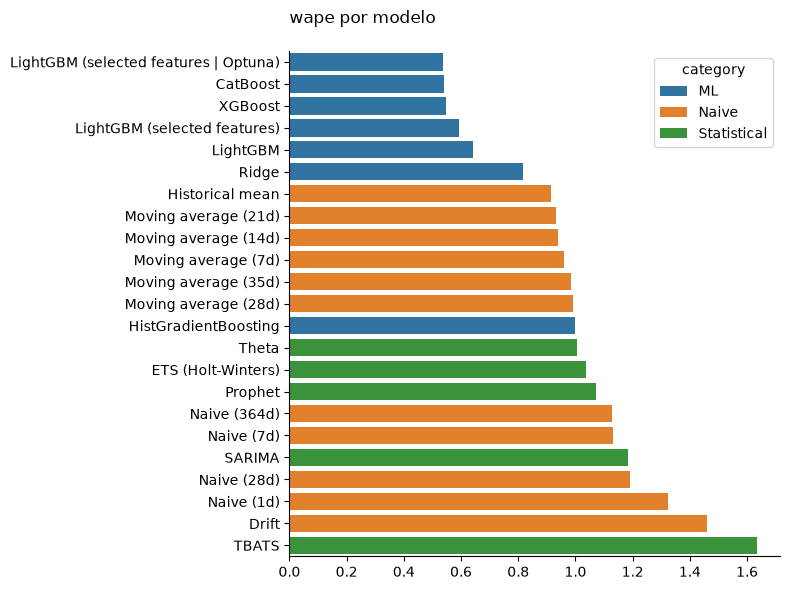

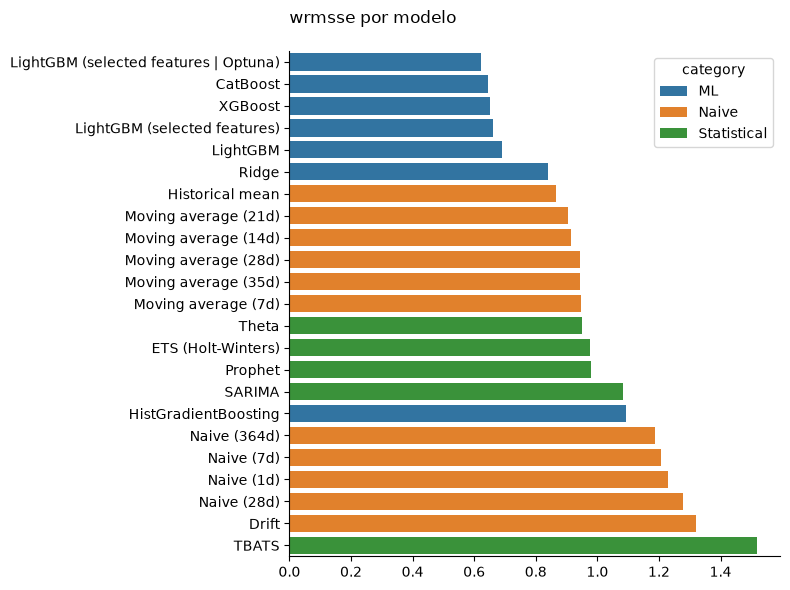

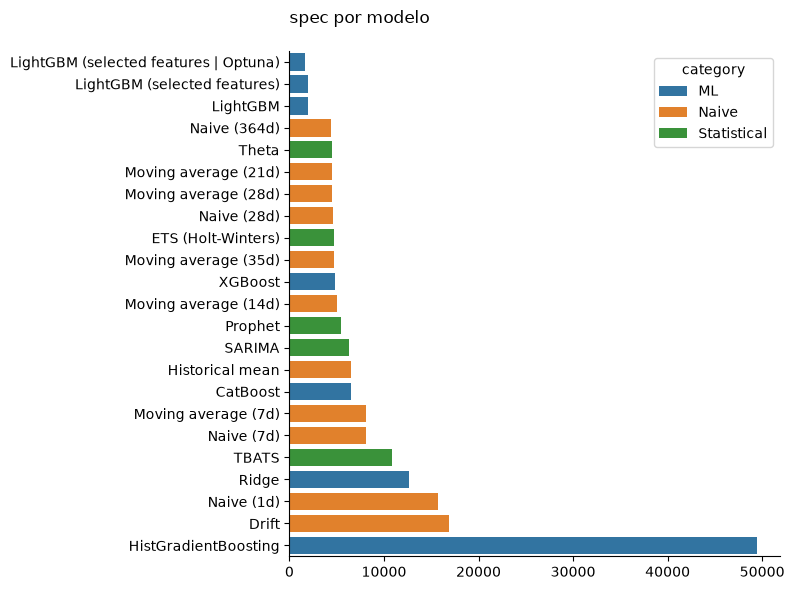

In [6]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [7]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(30_000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                             feature  mean_abs_shap
2                     avg_sell_price       6.435155
5                      price_vs_mean       4.951376
10                      price_vs_max       1.978238
11                days_since_release       0.191074
0                            item_id       0.172780
..                               ...            ...
87  rolling_min_lag364_window_size91       0.000174
68   rolling_min_lag28_window_size28       0.000087
54    rolling_min_lag1_window_size35       0.000075
84  rolling_min_lag364_window_size28       0.000063
79   rolling_min_lag91_window_size91       0.000007

[91 rows x 2 columns]


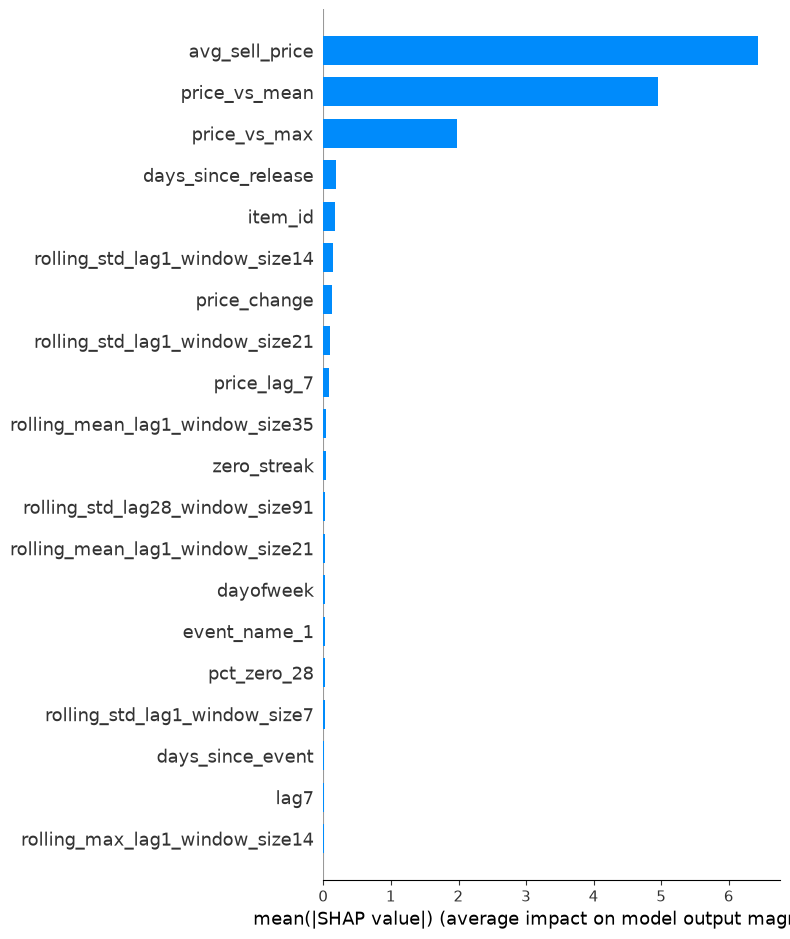

In [8]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

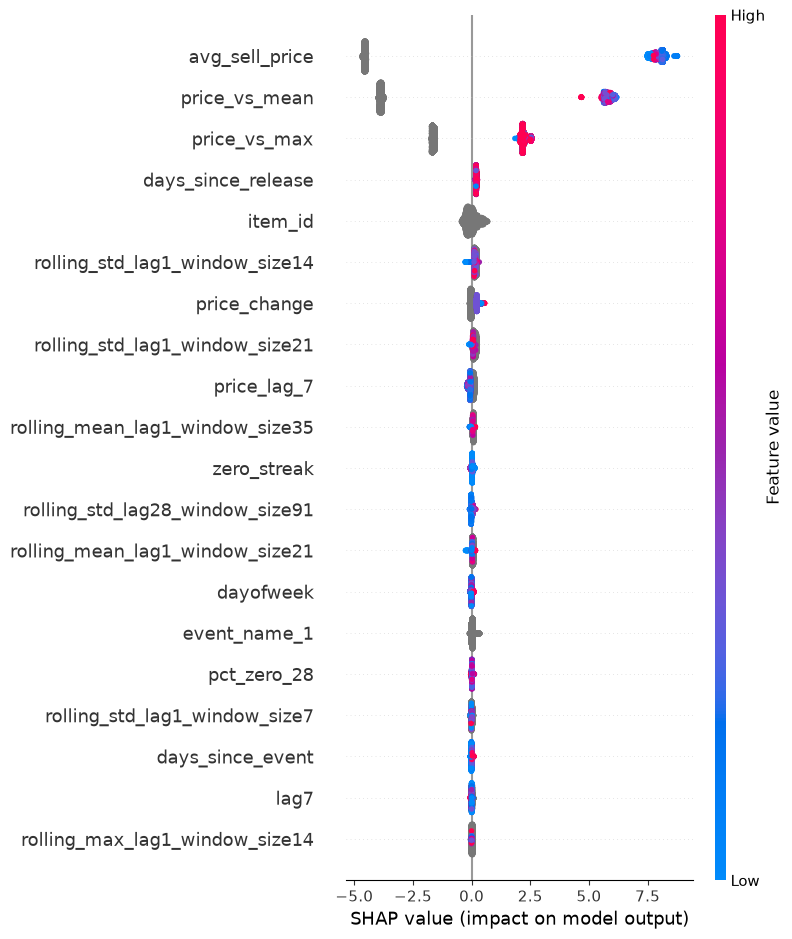

In [9]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [10]:
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, test=artifact['test'], target=artifact['target'],
                         explainer=explainer, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, target, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )

In [11]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 57.84%
Test WRMSSE: 0.6023


In [12]:
from src.evaluation.metrics import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(10)

/home/njimenez/Workspace/magister/forecast-tfm/notebooks/../src/evaluation/metrics.py:11: RuntimeWarning: invalid value encountered in scalar divide
  return np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()
/home/njimenez/Workspace/magister/forecast-tfm/notebooks/../src/evaluation/metrics.py:16: RuntimeWarning: invalid value encountered in scalar divide
  return (y_pred - y_true).sum() / np.abs(y_true).sum()


,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
FOODS_1_FOODS_FOODS_1_088_CA_1_CA,28,17,112.0,41.0,71.0,101.0,591.359985,0.023996,0.901786,-0.633929,0.736838,19.683168,24.309636,2.213182,29.526786
FOODS_1_FOODS_FOODS_1_170_CA_1_CA,28,21,84.0,102.0,-18.0,46.0,473.760010,0.019224,0.547619,0.214286,0.531580,-10.956522,0.593180,0.826271,6.723214
FOODS_1_FOODS_FOODS_1_055_CA_1_CA,28,18,108.0,71.0,37.0,83.0,473.040009,0.019194,0.768519,-0.342593,0.640319,12.481928,3.113990,1.240193,59.866071
FOODS_1_FOODS_FOODS_1_180_CA_1_CA,28,17,45.0,45.0,0.0,36.0,448.649994,0.018205,0.800000,0.000000,0.489389,0.000000,2.148546,1.060800,8.455357
FOODS_1_FOODS_FOODS_1_187_CA_1_CA,28,19,45.0,40.0,5.0,21.0,447.419983,0.018155,0.466667,-0.111111,0.334281,6.666667,1.109575,0.645008,10.687500
FOODS_1_FOODS_FOODS_1_012_CA_1_CA,28,23,78.0,88.0,-10.0,46.0,439.919983,0.017851,0.589744,0.128205,0.500683,-6.086957,0.747752,0.747002,11.026786
FOODS_1_FOODS_FOODS_1_043_CA_1_CA,28,27,220.0,213.0,7.0,99.0,431.200012,0.017497,0.450000,-0.031818,0.534294,1.979798,0.797527,0.783769,35.892857
FOODS_1_FOODS_FOODS_1_087_CA_1_CA,28,22,75.0,63.0,12.0,32.0,423.000000,0.017164,0.426667,-0.160000,0.374584,10.500000,0.967183,0.754717,14.107143
FOODS_1_FOODS_FOODS_1_110_CA_1_CA,28,26,179.0,200.0,-21.0,69.0,350.839996,0.014236,0.385475,0.117318,0.526128,-8.521739,0.536637,0.647819,11.901786


In [13]:
df_metrics.head(10)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
agg_id,,,,,,,,,,,,,,,
FOODS_1_FOODS_FOODS_1_088_CA_1_CA,28,17,112.0,41.0,71.0,101.0,591.359985,0.023996,0.901786,-0.633929,0.736838,19.683168,24.309636,2.213182,29.526786
FOODS_1_FOODS_FOODS_1_170_CA_1_CA,28,21,84.0,102.0,-18.0,46.0,473.760010,0.019224,0.547619,0.214286,0.531580,-10.956522,0.593180,0.826271,6.723214
FOODS_1_FOODS_FOODS_1_055_CA_1_CA,28,18,108.0,71.0,37.0,83.0,473.040009,0.019194,0.768519,-0.342593,0.640319,12.481928,3.113990,1.240193,59.866071
FOODS_1_FOODS_FOODS_1_180_CA_1_CA,28,17,45.0,45.0,0.0,36.0,448.649994,0.018205,0.800000,0.000000,0.489389,0.000000,2.148546,1.060800,8.455357
FOODS_1_FOODS_FOODS_1_187_CA_1_CA,28,19,45.0,40.0,5.0,21.0,447.419983,0.018155,0.466667,-0.111111,0.334281,6.666667,1.109575,0.645008,10.687500
FOODS_1_FOODS_FOODS_1_012_CA_1_CA,28,23,78.0,88.0,-10.0,46.0,439.919983,0.017851,0.589744,0.128205,0.500683,-6.086957,0.747752,0.747002,11.026786
FOODS_1_FOODS_FOODS_1_043_CA_1_CA,28,27,220.0,213.0,7.0,99.0,431.200012,0.017497,0.450000,-0.031818,0.534294,1.979798,0.797527,0.783769,35.892857
FOODS_1_FOODS_FOODS_1_087_CA_1_CA,28,22,75.0,63.0,12.0,32.0,423.000000,0.017164,0.426667,-0.160000,0.374584,10.500000,0.967183,0.754717,14.107143
FOODS_1_FOODS_FOODS_1_110_CA_1_CA,28,26,179.0,200.0,-21.0,69.0,350.839996,0.014236,0.385475,0.117318,0.526128,-8.521739,0.536637,0.647819,11.901786


In [19]:
df_pred.query('agg_id == "FOODS_1_FOODS_FOODS_1_088_CA_1_CA"')

,agg_id,date,sales,gross_sales,y_pred,error,abs_error,wape,bias
168854,FOODS_1_FOODS_FOODS_1_088_CA_1_CA,2016-05-10,0.0,0.000000,0.0,0.0,0.0,NaN,NaN
168853,FOODS_1_FOODS_FOODS_1_088_CA_1_CA,2016-05-09,2.0,10.560000,2.0,0.0,0.0,0.000000,-0.000000
168850,FOODS_1_FOODS_FOODS_1_088_CA_1_CA,2016-05-06,0.0,0.000000,0.0,0.0,0.0,NaN,NaN
168848,FOODS_1_FOODS_FOODS_1_088_CA_1_CA,2016-05-04,0.0,0.000000,0.0,0.0,0.0,NaN,NaN
168845,FOODS_1_FOODS_FOODS_1_088_CA_1_CA,2016-05-01,2.0,10.560000,2.0,0.0,0.0,0.000000,-0.000000
168841,FOODS_1_FOODS_FOODS_1_088_CA_1_CA,2016-04-27,0.0,0.000000,0.0,0.0,0.0,NaN,NaN
168840,FOODS_1_FOODS_FOODS_1_088_CA_1_CA,2016-04-26,0.0,0.000000,0.0,0.0,0.0,NaN,NaN
168866,FOODS_1_FOODS_FOODS_1_088_CA_1_CA,2016-05-22,0.0,0.000000,0.0,0.0,0.0,NaN,NaN
168865,FOODS_1_FOODS_FOODS_1_088_CA_1_CA,2016-05-21,0.0,0.000000,0.0,0.0,0.0,NaN,NaN
168864,FOODS_1_FOODS_FOODS_1_088_CA_1_CA,2016-05-20,0.0,0.000000,0.0,0.0,0.0,NaN,NaN


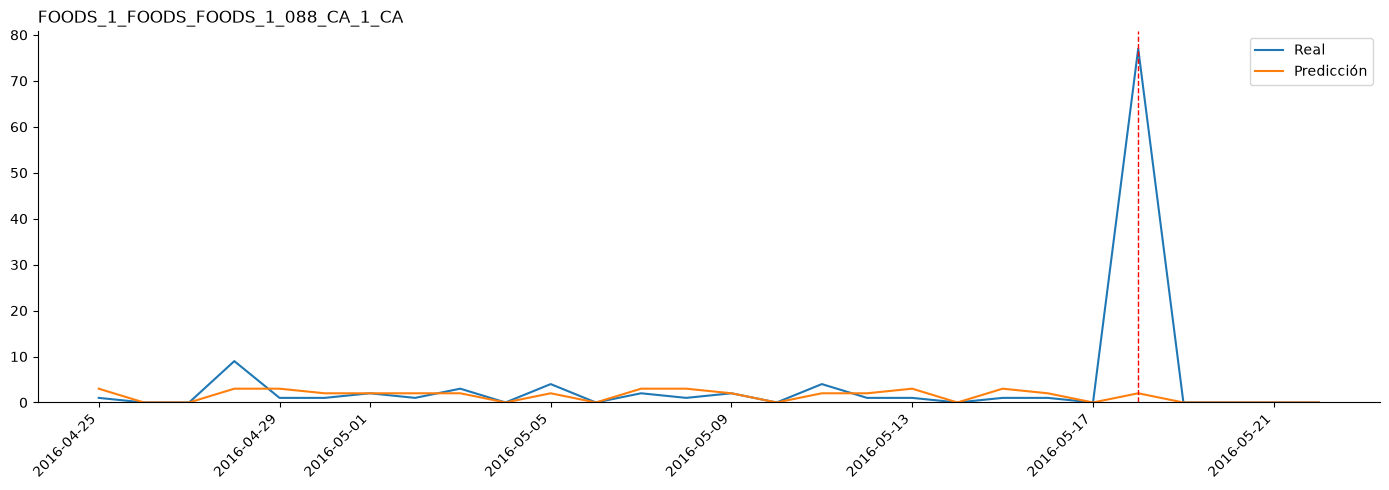

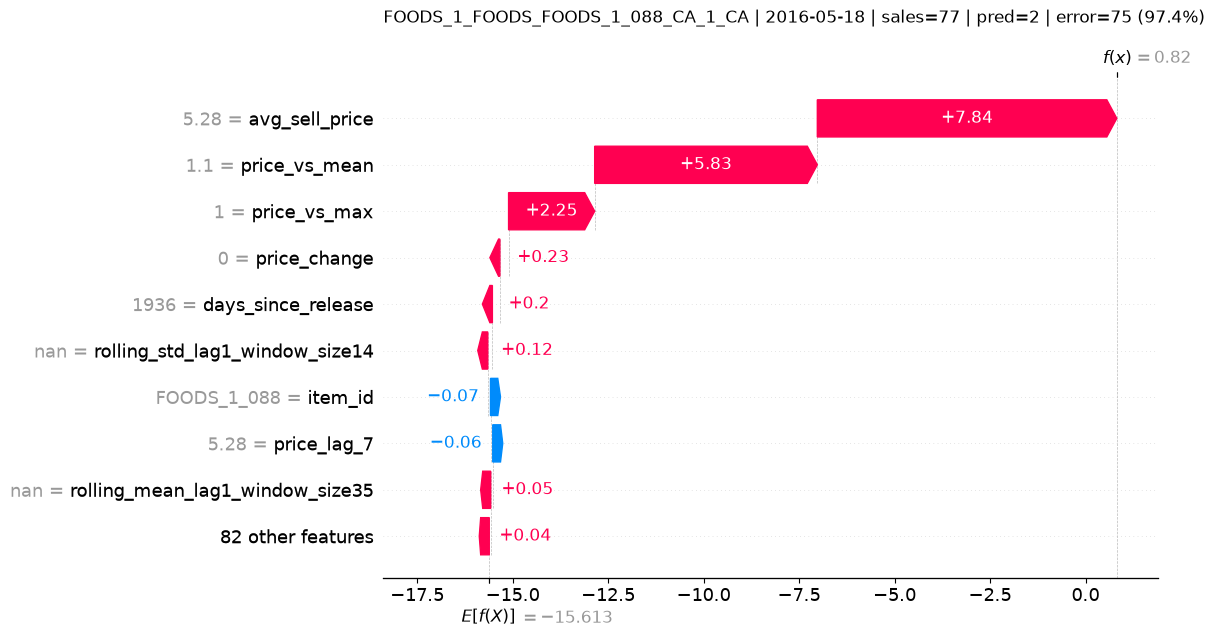

In [17]:
analizar_prediccion(agg_id='FOODS_1_FOODS_FOODS_1_088_CA_1_CA',date='2016-05-18')